In [1]:
# ── Cell 1: load results ─────────────────────────────────────────────────────
import glob
import pandas as pd

OUTPUT_CSV = "./results/results_dp_sbm_polblogs.csv"   # match OUTPUT_CSV in script_polblogs.py

shard_files = sorted(glob.glob(f"{OUTPUT_CSV}.shard*"))
if shard_files:
    df = pd.concat([pd.read_csv(f) for f in shard_files], ignore_index=True)
    print(f"Loaded {len(shard_files)} shard files, {len(df)} rows total.")
else:
    df = pd.read_csv(OUTPUT_CSV)
    print(f"Loaded {OUTPUT_CSV}, {len(df)} rows.")

# ── Drop the sigma=0.1 grid point ──────────────────────────────────────────
# At sigma=0.1 the accountant returns epsilon ~ 1605 (1.6e+03). np.exp(epsilon)
# in edge_flip/p_flip overflows float64 there (exp overflows above ~709.8), so
# that point's beta/NMI values are unreliable. It is also no privacy at all
# (epsilon in the thousands), so it carries no information -- exclude it from
# every plot below.
_n_before = len(df)
df = df[df["sigma"] != 0.1].reset_index(drop=True)
print(f"Excluded sigma=0.1 (epsilon~1.6e+03, overflow): dropped {_n_before - len(df)} rows, {len(df)} remain.")

df.head()

Loaded ./results/results_dp_sbm_polblogs.csv, 240 rows.
Excluded sigma=0.1 (epsilon~1.6e+03, overflow): dropped 40 rows, 200 remain.


,N,sigma,epsilon,rep,method,epsilon_gamma,epsilon_beta,epsilon_rho,epochs,epochs_gamma,epochs_beta,delta,beta_true_00,beta_true_01,beta_true_11,beta_est_00,beta_est_01,beta_est_11,nmi
0,1222,0.5,75.260893,0,edge_flip_vem,NaN,NaN,NaN,300.000000,NaN,NaN,0.00001,0.042592,0.004226,0.038825,0.002108,0.022182,0.159272,0.000435
1,1222,0.5,75.260893,0,sbm_dpsgd_all_noised,70.772017,12.423111,1.033894,10.999985,5.999992,4.999993,0.00001,0.042592,0.004226,0.038825,0.106011,0.012516,0.142520,0.041655
2,1222,0.5,75.260893,1,edge_flip_vem,NaN,NaN,NaN,288.000000,NaN,NaN,0.00001,0.042592,0.004226,0.038825,0.159272,0.022182,0.002108,0.000435
3,1222,0.5,75.260893,1,sbm_dpsgd_all_noised,70.772017,12.423111,1.033894,10.999985,5.999992,4.999993,0.00001,0.042592,0.004226,0.038825,0.118593,0.004788,0.135494,0.322850
4,1222,0.5,75.260893,2,edge_flip_vem,NaN,NaN,NaN,267.000000,NaN,NaN,0.00001,0.042592,0.004226,0.038825,0.002108,0.022182,0.159272,0.000435


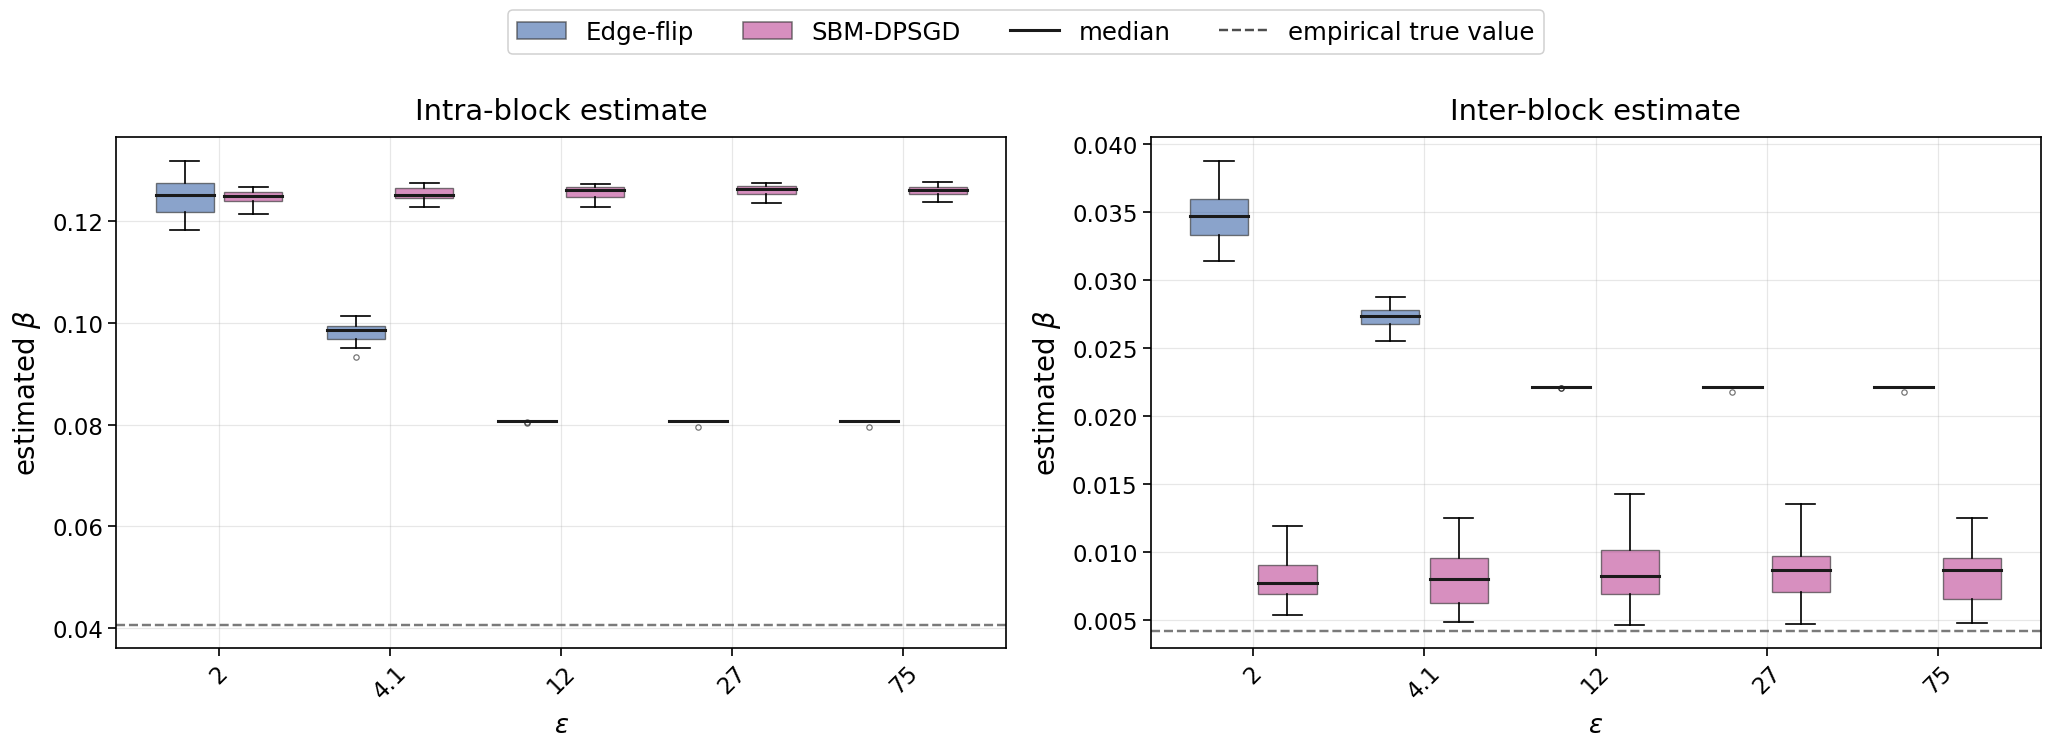

In [2]:
# ── Cell 2: Boxplots of estimated beta vs epsilon ────────────────────────────
# polblogs is a single fixed graph, so there is no N (or regime) sweep to put
# on rows -- the figure is one row of two large panels, intra and inter, sized
# to match the row-per-N figures in the synthetic notebooks.
# Colours/labels/median style come from plot_style.py so every figure in the
# thesis uses the same colour for the same method.
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

from plot_style import (apply_style, figsize, grouped_boxplot, method_color,
                        method_label, order_methods, reference_line,
                        BOX_ALPHA, MEDIAN_COLOR, REFERENCE_COLOR)

apply_style()

methods = order_methods(df["method"].unique())

# Per-panel inches before FIG_SCALE -- the single knob for retuning size.
PANEL_W, PANEL_H = 7.0, 5.0

true_00 = df["beta_true_00"].iloc[0]
true_01 = df["beta_true_01"].iloc[0]
true_11 = df["beta_true_11"].iloc[0]
df["intra_est"] = df[["beta_est_00", "beta_est_11"]].mean(axis=1)

fig, axes = plt.subplots(1, 2, figsize=figsize(PANEL_W * 2, PANEL_H))

for ax, (est_col, true_val, title) in zip(axes, [
    ("intra_est", (true_00 + true_11) / 2, "Intra-block estimate"),
    ("beta_est_01", true_01, "Inter-block estimate"),
]):
    grouped_boxplot(ax, df, est_col, methods=methods)
    reference_line(ax, true_val)
    ax.set_title(title, fontsize=19, pad=12)
    ax.set_xlabel(r"$\epsilon$")
    ax.set_ylabel(r"estimated $\beta$", fontsize=18)

handles = [Patch(facecolor=method_color(m), alpha=BOX_ALPHA, edgecolor="#333333",
                 label=method_label(m)) for m in methods]
handles += [
    Line2D([0], [0], color=MEDIAN_COLOR, linewidth=2.0, label="median"),
    Line2D([0], [0], color=REFERENCE_COLOR, linestyle="--", linewidth=1.6,
           label="empirical true value"),
]
fig.legend(handles=handles, loc="upper center", ncol=len(handles),
           fontsize=16, frameon=True, bbox_to_anchor=(0.5, 1.03))

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

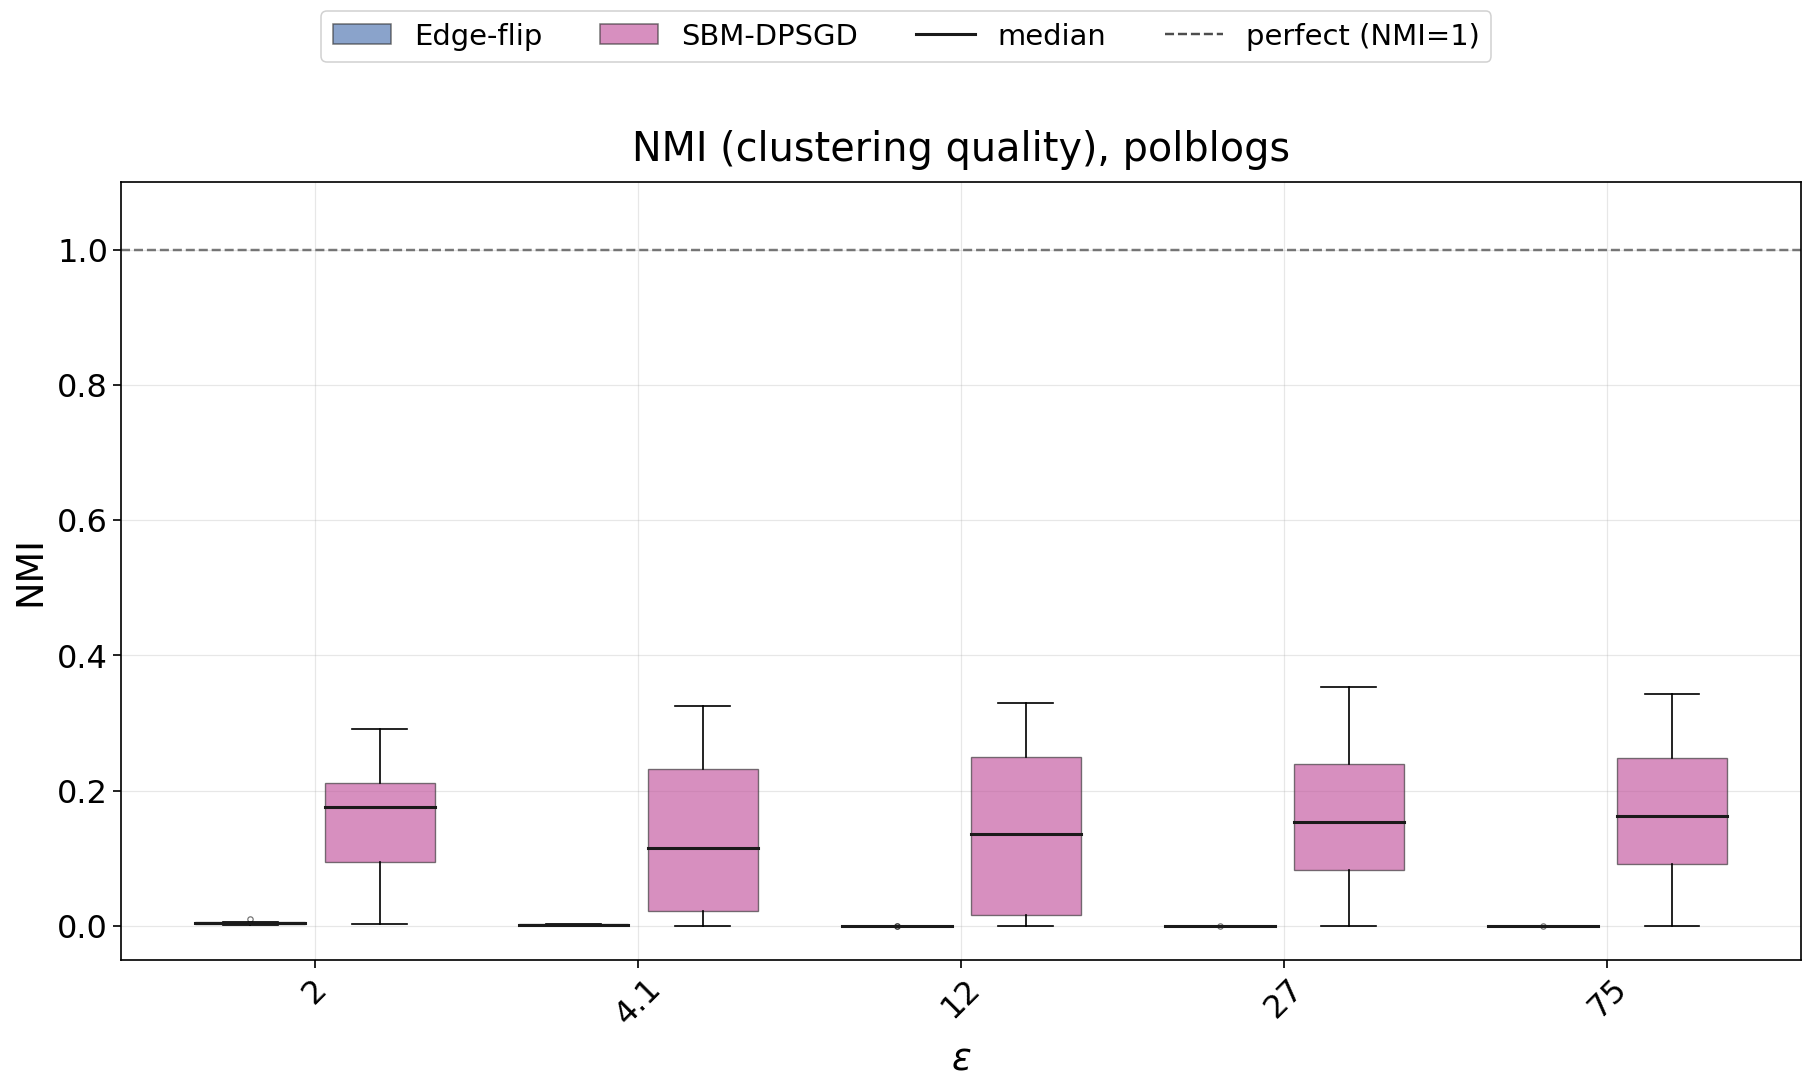

In [3]:
# ── Cell 3: Boxplots of NMI vs epsilon ───────────────────────────────────────
# Single fixed graph, so a single large panel.
#
# SIZE: enlarged relative to the other panels in this notebook, on both axes
# of "bigger" -- a wider/taller canvas (PANEL_W/PANEL_H) AND larger type
# (NMI_RC). The two are independent knobs: point sizes are absolute, so
# growing the canvas alone would leave the text looking smaller on it. Tick
# labels can only be resized through rcParams, so the type bump goes through
# a rc_context, scoped to this figure so the rest of the notebook keeps the
# thesis-wide plot_style sizing.
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

from plot_style import (apply_style, figsize, grouped_boxplot, method_color,
                        method_label, order_methods, reference_line,
                        BOX_ALPHA, MEDIAN_COLOR, REFERENCE_COLOR)

apply_style()

methods = order_methods(df["method"].unique())
sub = df.dropna(subset=["nmi"])

PANEL_W, PANEL_H = 12.5, 7.5

NMI_RC = {
    "font.size": 20,
    "axes.labelsize": 24,
    "xtick.labelsize": 21,
    "ytick.labelsize": 21,
    "legend.fontsize": 20,
}

with plt.rc_context(NMI_RC):
    fig, ax = plt.subplots(figsize=figsize(PANEL_W, PANEL_H))

    grouped_boxplot(ax, sub, "nmi", methods=methods)
    reference_line(ax, 1.0)
    ax.set_ylim(-0.05, 1.1)
    ax.set_title("NMI (clustering quality), polblogs", fontsize=26, pad=14)
    ax.set_xlabel(r"$\epsilon$")
    ax.set_ylabel("NMI", fontsize=24)

    handles = [Patch(facecolor=method_color(m), alpha=BOX_ALPHA,
                     edgecolor="#333333", label=method_label(m))
               for m in methods]
    handles += [
        Line2D([0], [0], color=MEDIAN_COLOR, linewidth=2.0, label="median"),
        Line2D([0], [0], color=REFERENCE_COLOR, linestyle="--", linewidth=1.6,
               label="perfect (NMI=1)"),
    ]
    # Legend ABOVE the axes rather than loc="best": at this type size the box
    # is large enough that an in-axes placement covers data.
    fig.legend(handles=handles, loc="upper center", ncol=len(handles),
               fontsize=19, frameon=True, bbox_to_anchor=(0.5, 1.0))

    fig.tight_layout(rect=[0, 0, 1, 0.91])
    fig.savefig("figures/nmi_polblogs.png", dpi=200)
    plt.show()

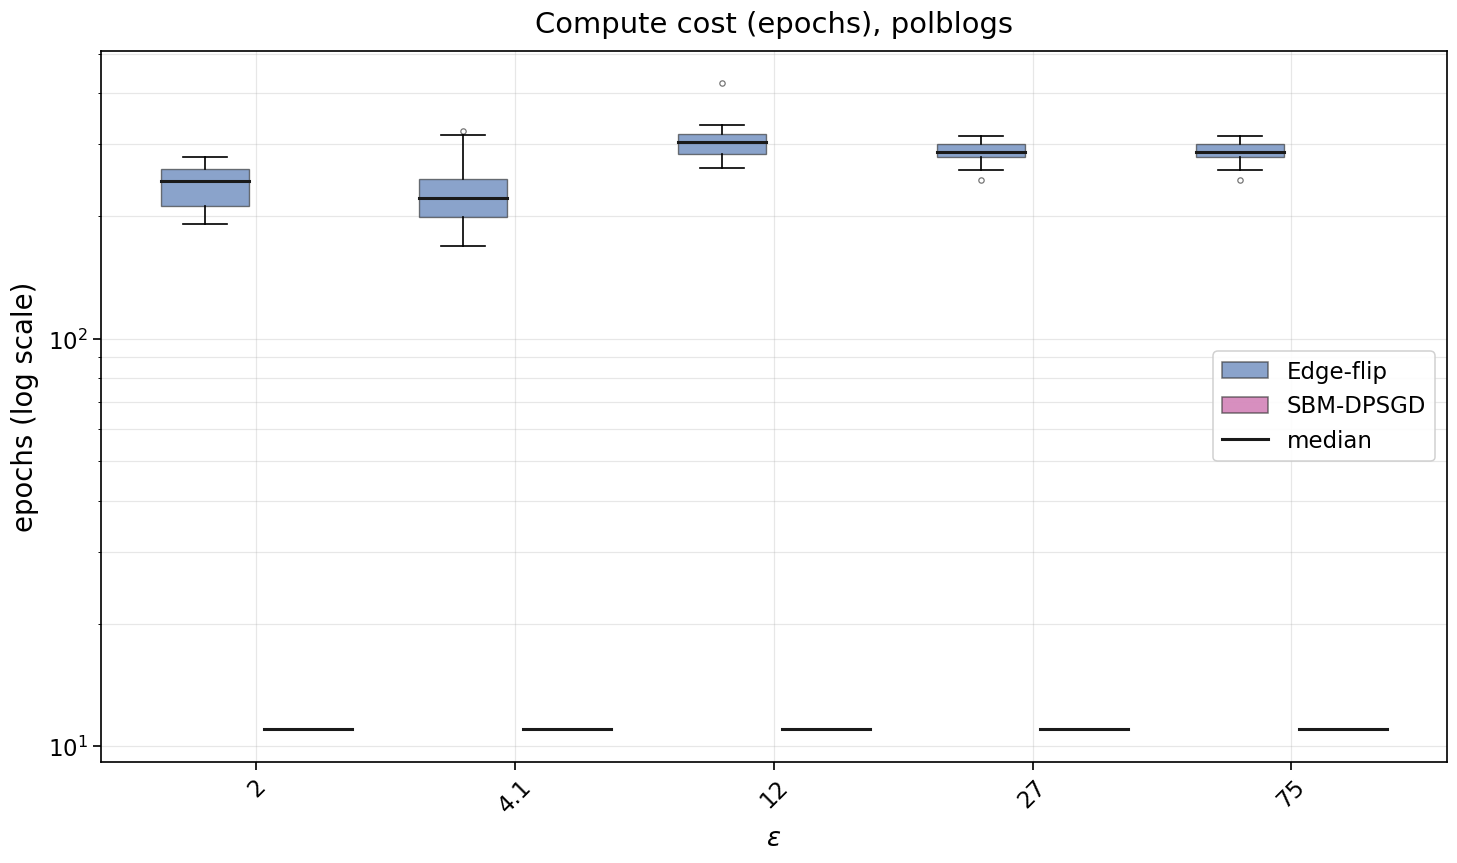

In [4]:
# ── Cell 4: Boxplots of compute cost (epochs) vs epsilon ─────────────────────
# Log scale: the methods differ by ~1-2 orders of magnitude, so a linear axis
# squashes the cheaper one flat near zero.
# CAVEAT: an epoch is NOT wall-clock comparable across methods -- a VEM epoch
# is a dense O(N^2) matmul pass, an SBM-DPSGD epoch is a sampled
# per-example-autodiff pass.
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

from plot_style import (apply_style, figsize, grouped_boxplot, method_color,
                        method_label, order_methods, BOX_ALPHA, MEDIAN_COLOR)

apply_style()

methods = order_methods(df["method"].unique())

PANEL_W, PANEL_H = 10.0, 6.0

fig, ax = plt.subplots(figsize=figsize(PANEL_W, PANEL_H))

grouped_boxplot(ax, df, "epochs", methods=methods)
ax.set_yscale("log")
ax.set_title("Compute cost (epochs), polblogs", fontsize=19, pad=12)
ax.set_xlabel(r"$\epsilon$")
ax.set_ylabel("epochs (log scale)", fontsize=18)
ax.grid(alpha=0.3, which="both")

handles = [Patch(facecolor=method_color(m), alpha=BOX_ALPHA, edgecolor="#333333",
                 label=method_label(m)) for m in methods]
handles.append(Line2D([0], [0], color=MEDIAN_COLOR, linewidth=2.0, label="median"))
ax.legend(handles=handles, fontsize=15, loc="best")

plt.tight_layout()
plt.show()

In [5]:
# ── Cell 5: dataset description numbers (fills in the methods sentence) ──────
# Reproduces load_polblogs() + empirical_betas() from script_polblogs.py
# EXACTLY -- read the GML, collapse the MultiDiGraph to a simple undirected
# graph, keep the largest connected component -- and reports the counts,
# block probabilities and sparsity descriptors of that final graph, i.e. the
# object every experiment in this notebook was actually run on.
import math

import networkx as nx
import numpy as np

DATA_PATH = "./polblogs-1.gml"          # match DATA_PATH in script_polblogs.py
LABEL_NAME = {0: "liberal", 1: "conservative"}   # the "value" node attribute

G_raw = nx.read_gml(DATA_PATH)
G = nx.Graph(G_raw)                     # MultiDiGraph -> simple undirected
G = G.to_undirected()
lcc_nodes = max(nx.connected_components(G), key=len)
G_lcc = G.subgraph(lcc_nodes).copy()
labels = np.array([d["value"] for _, d in G_lcc.nodes(data=True)])
A_np = nx.to_numpy_array(G_lcc)

n_nodes = G_lcc.number_of_nodes()
n_edges_all = G_lcc.number_of_edges()               # includes self-loops
n_selfloops = nx.number_of_selfloops(G_lcc)
n_edges = n_edges_all - n_selfloops                 # distinct-pair edges (i < j)
counts = {v: int((labels == v).sum()) for v in sorted(set(labels))}
n_lib, n_con = counts.get(0, 0), counts.get(1, 0)

print("── preprocessing trail ─────────────────────────────────────────────")
print(f"raw GML                     : {G_raw.number_of_nodes()} nodes, "
      f"{G_raw.number_of_edges()} directed edges ({type(G_raw).__name__})")
print(f"simple + undirected         : {G.number_of_nodes()} nodes, "
      f"{G.number_of_edges()} edges, {nx.number_connected_components(G)} components")
print(f"largest connected component : {n_nodes} nodes, {n_edges_all} edges "
      f"(of which {n_selfloops} self-loops)")
print()
print("── numbers for the sentence ────────────────────────────────────────")
print(f"N                = {n_nodes}")
print(f"|E|              = {n_edges}      (distinct-pair edges, self-loops excluded)")
print(f"|E| incl. loops  = {n_edges_all}      (networkx edge count)")
print(f"liberal (0)      = {n_lib}")
print(f"conservative (1) = {n_con}")
print()
print("── filled-in sentence ──────────────────────────────────────────────")
print(f"After this preprocessing, the resulting network contains N = {n_nodes:,} nodes "
      f"and |E| = {n_edges:,} edges, with political affiliations of {n_lib:,} liberal "
      f"and {n_con:,} conservative blogs.")

# ── Empirical block probabilities ──────────────────────────────────────────
# Byte-for-byte the estimator in script_polblogs.empirical_betas(): block-pair
# edge density under the ground-truth labels, which is what the CSV's
# beta_true_* columns hold and what both DP methods are trying to recover.
# (Numerators include the 3 self-loops at half weight, exactly as the script
# counts them; the effect is in the 6th decimal -- see the check below.)
K = 2
beta_emp = np.zeros((K, K))
for k in range(K):
    for l in range(k, K):
        mk, ml = labels == k, labels == l
        if k == l:
            num = A_np[np.ix_(mk, mk)].sum() / 2.0
            den = mk.sum() * (mk.sum() - 1) / 2.0
        else:
            num = A_np[np.ix_(mk, ml)].sum()
            den = mk.sum() * ml.sum()
        beta_emp[k, l] = beta_emp[l, k] = num / den if den > 0 else 0.0

print()
print("── empirical block probabilities (ground-truth labels) ─────────────")
print(f"beta_00  (liberal-liberal)          = {beta_emp[0, 0]:.6f}   "
      f"(1 edge per {1 / beta_emp[0, 0]:,.0f} possible pairs)")
print(f"beta_11  (conservative-conservative)= {beta_emp[1, 1]:.6f}   "
      f"(1 edge per {1 / beta_emp[1, 1]:,.0f} possible pairs)")
print(f"beta_01  (across the divide)        = {beta_emp[0, 1]:.6f}   "
      f"(1 edge per {1 / beta_emp[0, 1]:,.0f} possible pairs)")
beta_intra = (beta_emp[0, 0] + beta_emp[1, 1]) / 2
print(f"mean intra-block p = {beta_intra:.6f}   inter-block q = {beta_emp[0, 1]:.6f}")
print(f"out/in ratio q/p   = {beta_emp[0, 1] / beta_intra:.4f}   "
      f"(assortativity p/q = {beta_intra / beta_emp[0, 1]:.1f}x)")

# ── How sparse is it? ──────────────────────────────────────────────────────
# Two reference points, both from the synthetic sparsity study: the
# connectivity threshold log(n)/n and the constant-average-degree scale 5/n.
degrees = A_np.sum(axis=1) - np.diag(A_np)          # self-loops not counted
density = 2 * n_edges / (n_nodes * (n_nodes - 1))
thr_log, thr_const = math.log(n_nodes) / n_nodes, 5.0 / n_nodes

print()
print("── sparsity descriptors ────────────────────────────────────────────")
print(f"edge density        = {density:.6f}   ({100 * density:.2f}% of the "
      f"{n_nodes * (n_nodes - 1) // 2:,} possible pairs are edges)")
print(f"mean degree         = {degrees.mean():.2f}   "
      f"median = {np.median(degrees):.0f}   min = {degrees.min():.0f}   "
      f"max = {degrees.max():.0f}")
print(f"degree distribution : heavy-tailed -- top 1% of blogs hold "
      f"{100 * np.sort(degrees)[-max(1, n_nodes // 100):].sum() / degrees.sum():.1f}% "
      f"of edge endpoints")
print(f"log(n)/n            = {thr_log:.6f}   -> density is "
      f"{density / thr_log:.1f}x the connectivity threshold "
      f"(mean degree {degrees.mean() / math.log(n_nodes):.1f}x log n = {math.log(n_nodes):.1f})")
print(f"5/n                 = {thr_const:.6f}   -> density is "
      f"{density / thr_const:.1f}x the constant-average-degree scale")
print(f"=> DENSER than either synthetic sparse regime, but still sparse in "
      f"absolute terms:\n   {100 * (1 - density):.2f}% of node pairs are non-edges, "
      f"and the inter-block\n   probability q = {beta_emp[0, 1]:.4f} is the "
      f"regime-defining small number.")

# ── Cross-checks against the results CSV ───────────────────────────────────
if "df" in dir() and "N" in df.columns:
    n_csv = sorted(df["N"].unique())
    print(f"\ncross-check N        : CSV = {n_csv}, recomputed = {n_nodes} "
          f"({'match' if n_csv == [n_nodes] else 'MISMATCH -- investigate'})")
    csv_beta = df[["beta_true_00", "beta_true_01", "beta_true_11"]].iloc[0].values
    mine = np.array([beta_emp[0, 0], beta_emp[0, 1], beta_emp[1, 1]])
    print(f"cross-check beta_true: CSV = {np.round(csv_beta, 6)}, "
          f"recomputed = {np.round(mine, 6)} "
          f"({'match' if np.allclose(csv_beta, mine, atol=1e-6) else 'MISMATCH -- investigate'})")

── preprocessing trail ─────────────────────────────────────────────
raw GML                     : 1490 nodes, 19090 directed edges (MultiDiGraph)
simple + undirected         : 1490 nodes, 16718 edges, 268 components
largest connected component : 1222 nodes, 16717 edges (of which 3 self-loops)

── numbers for the sentence ────────────────────────────────────────
N                = 1222
|E|              = 16714      (distinct-pair edges, self-loops excluded)
|E| incl. loops  = 16717      (networkx edge count)
liberal (0)      = 586
conservative (1) = 636

── filled-in sentence ──────────────────────────────────────────────
After this preprocessing, the resulting network contains N = 1,222 nodes and |E| = 16,714 edges, with political affiliations of 586 liberal and 636 conservative blogs.

── empirical block probabilities (ground-truth labels) ─────────────
beta_00  (liberal-liberal)          = 0.042592   (1 edge per 23 possible pairs)
beta_11  (conservative-conservative)= 0.038825   (1 